In [ ]:
# ============================================
# 📌 Step 1: Import Libraries
# ============================================
# Data handling, math, graphs & ML model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from google.colab import files

sns.set(style="whitegrid")

# ============================================
# 📌 Step 2: Upload CSV
# ============================================
print("📂 Krupaya apni habit tracking CSV file upload karo")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("✅ Data successfully load ho gaya!\n")
print(df.head())

# Expected Columns: user_id, habit_name, date, completed (0/1)
df['date'] = pd.to_datetime(df['date'])

# ============================================
# 📌 Step 3: Feature Engineering
# ============================================

# ✅ Streak Calculation Function (fixed & accurate)
def calculate_avg_streak(series):
    streaks = []
    current_streak = 0

    for value in series:
        if value == 1:
            current_streak += 1
        else:
            if current_streak > 0:
                streaks.append(current_streak)
            current_streak = 0

    if current_streak > 0:
        streaks.append(current_streak)

    return np.mean(streaks) if streaks else 0

# ✅ Create habit summary table
habit_summary = df.groupby(['user_id','habit_name']).agg(
    completion_rate = ('completed','mean'),
    avg_streak = ('completed', calculate_avg_streak),
    consistency = ('completed','std')
).reset_index()

habit_summary['consistency'] = habit_summary['consistency'].fillna(0)

# ✅ Habit labeling rules
def label_habit(row):
    if row['completion_rate'] < 0.5:
        return "Needs Improvement"
    elif row['completion_rate'] < 0.8:
        return "Okay"
    else:
        return "Strong"

habit_summary['label'] = habit_summary.apply(label_habit, axis=1)

print("\n📊 Habit Summary with Labels:")
print(habit_summary)

# ============================================
# 📌 Step 4: Train ML Model
# ============================================
X = habit_summary[['completion_rate','avg_streak','consistency']]
y = habit_summary['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n📈 Model Performance:")
print(classification_report(y_test, y_pred))

# ============================================
# 📌 Step 5: Visualizations
# ============================================

# 1. Completion Rate Distribution
plt.figure(figsize=(6,4))
sns.histplot(habit_summary['completion_rate'], bins=10, kde=True)
plt.title("Completion Rate Distribution")
plt.xlabel("Completion Rate")
plt.ylabel("Count")
plt.show()

# 2. Habit Status Count
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=habit_summary)
plt.title("Habit Categories")
plt.xlabel("Category")
plt.ylabel("Number of Habits")
plt.show()

# 3. Completion Rate per Habit
plt.figure(figsize=(10,5))
sns.barplot(x='habit_name', y='completion_rate', hue='label', data=habit_summary)
plt.xticks(rotation=45)
plt.title("Completion Rate per Habit")
plt.show()

# 4. Daily Completion Heatmap
plt.figure(figsize=(12,6))
heatmap_data = df.pivot_table(
    index='habit_name',
    columns='date',
    values='completed',
    aggfunc='mean'
)
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Daily Completion Heatmap (per Habit)")
plt.xlabel("Date")
plt.ylabel("Habit")
plt.show()

# 5. Trend Line (Completion Over Time per Habit)
plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='completed', hue='habit_name', data=df, estimator='mean')
plt.title("Habit Completion Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Completion (0-1)")
plt.show()

# 6. Boxplot of Completion Rates
plt.figure(figsize=(8,5))
sns.boxplot(x='habit_name', y='completion_rate', data=habit_summary)
plt.xticks(rotation=45)
plt.title("Completion Rate Variation per Habit")
plt.show()

# 7. User-wise Comparison
plt.figure(figsize=(8,5))
sns.barplot(x='user_id', y='completion_rate', hue='habit_name', data=habit_summary)
plt.title("User-wise Habit Performance")
plt.show()

# 8. Feature Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(habit_summary[['completion_rate','avg_streak','consistency']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ============================================
# 📌 Step 6: Suggestions
# ============================================
print("\n💡 Suggestions:")
for _, row in habit_summary.iterrows():
    print(f"- {row['habit_name']} → {row['label']} (Completion Rate: {row['completion_rate']:.2f})")


📂 Krupaya apni habit tracking CSV file upload karo


Saving Book1.xlsx to Book1.xlsx


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 15-16: invalid continuation byte

📂 Krupaya apni habit tracking file upload karo (CSV or Excel)


Saving Book1.xlsx to Book1 (2).xlsx
✅ Excel file loaded successfully!

✅ Data Loaded Successfully!

  user_id habit_name       date  completed
0  user_1    Reading 2025-07-15          1
1  user_1    Reading 2025-07-16          0
2  user_1    Reading 2025-07-17          1
3  user_1    Reading 2025-07-18          0
4  user_1    Reading 2025-07-19          0

📊 Habit Summary with Labels:
  user_id habit_name  completion_rate  avg_streak  consistency label
0  user_1    Cooking              0.6    1.800000     0.498273  Okay
1  user_1   Exercise              0.5    2.142857     0.508548  Okay
2  user_1    Reading              0.6    2.000000     0.498273  Okay
3  user_1       Yoga              0.7    3.000000     0.466092  Okay

📈 Model Performance:
              precision    recall  f1-score   support

        Okay       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00    

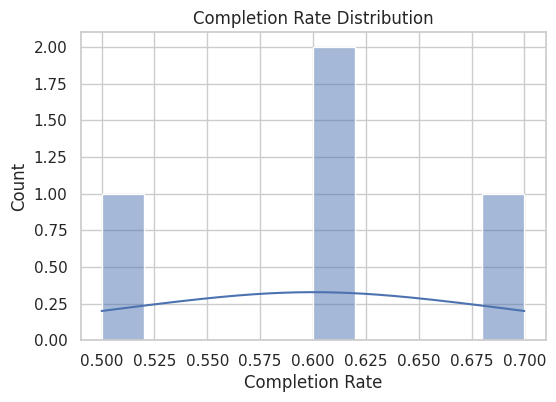

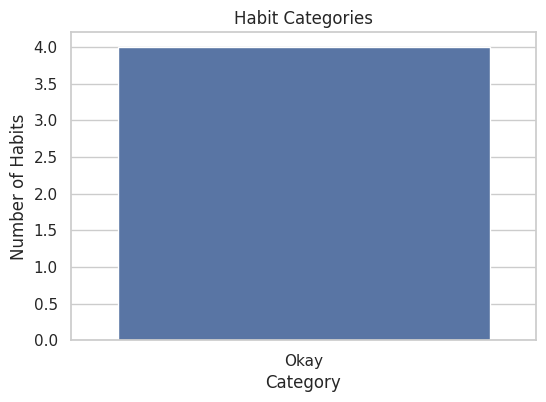

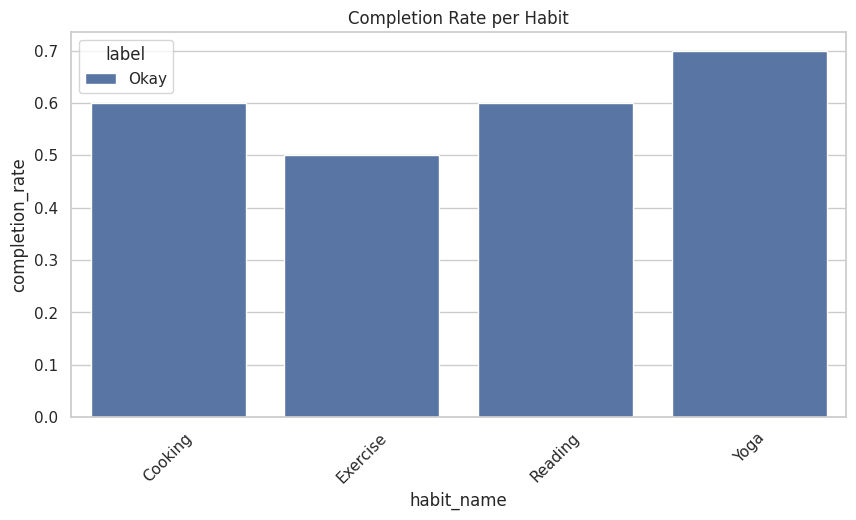

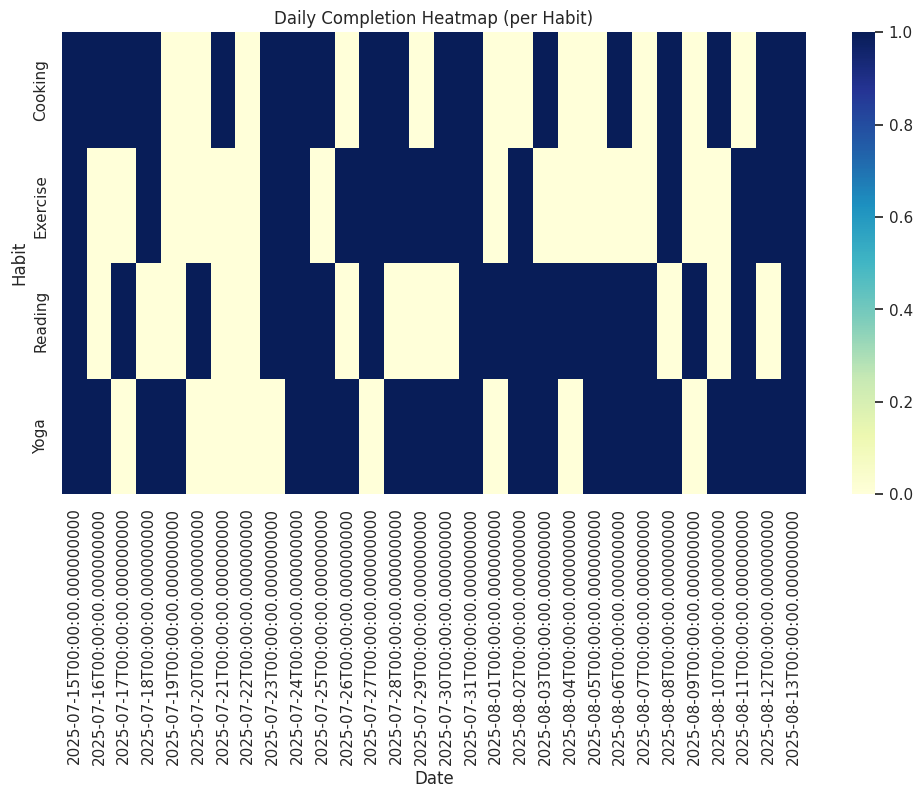

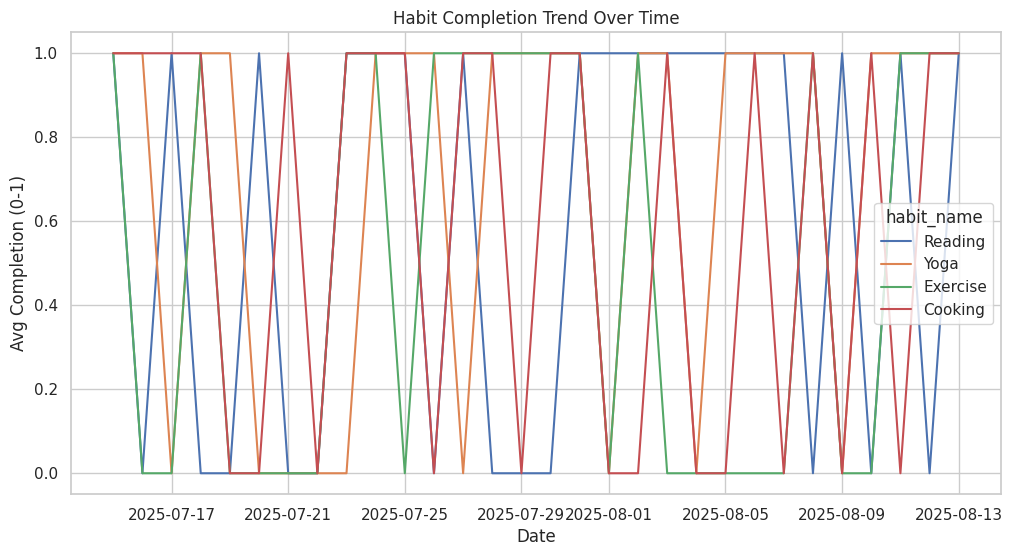

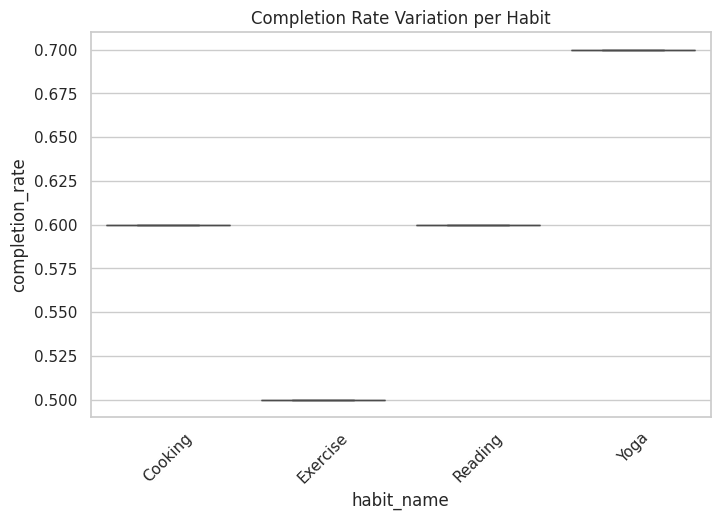

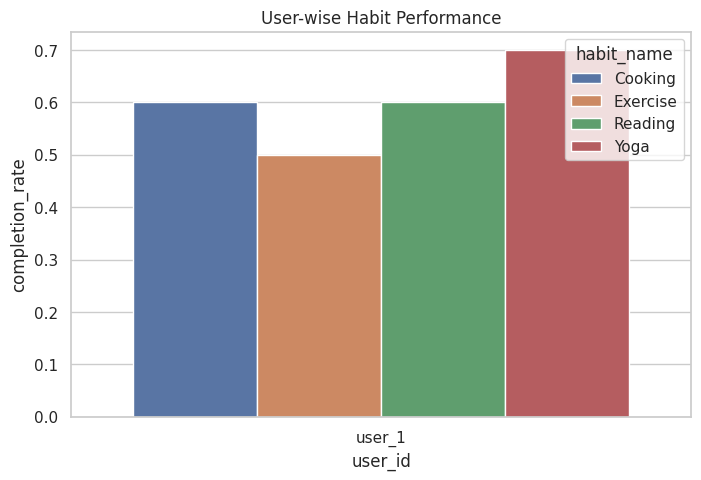

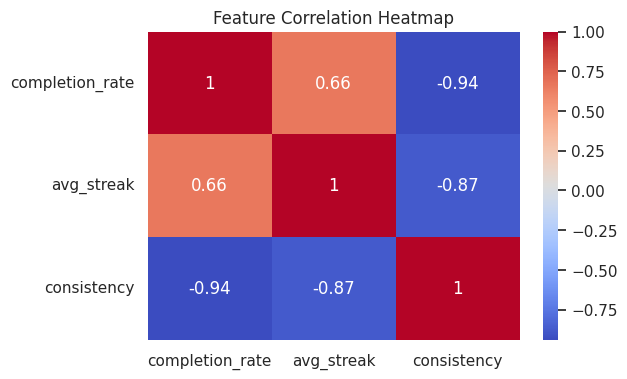


💡 Suggestions:
- Cooking → Okay (Completion Rate: 0.60)
- Exercise → Okay (Completion Rate: 0.50)
- Reading → Okay (Completion Rate: 0.60)
- Yoga → Okay (Completion Rate: 0.70)


In [ ]:
# ============================================
# 📌 Step 1: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from google.colab import files

sns.set(style="whitegrid")

# ============================================
# 📌 Step 2: Upload Excel/CSV File
# ============================================
print("📂 Krupaya apni habit tracking file upload karo (CSV or Excel)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ✅ Check file type and load accordingly
if filename.lower().endswith(".xlsx") or filename.lower().endswith(".xls"):
    df = pd.read_excel(filename)
    print("✅ Excel file loaded successfully!")

else:
    # For CSV try multiple encodings
    encodings_to_try = ['utf-8', 'latin1', 'ISO-8859-1', 'cp1252']
    for enc in encodings_to_try:
        try:
            df = pd.read_csv(filename, encoding=enc)
            print(f"✅ CSV loaded using encoding: {enc}")
            break
        except Exception as e:
            print(f"❌ Failed with encoding: {enc}")

print("\n✅ Data Loaded Successfully!\n")
print(df.head())

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# ============================================
# 📌 Step 3: Feature Engineering
# ============================================

def calculate_avg_streak(series):
    streaks = []
    current_streak = 0

    for value in series:
        if value == 1:
            current_streak += 1
        else:
            if current_streak > 0:
                streaks.append(current_streak)
            current_streak = 0

    if current_streak > 0:
        streaks.append(current_streak)

    return np.mean(streaks) if streaks else 0

habit_summary = df.groupby(['user_id','habit_name']).agg(
    completion_rate=('completed','mean'),
    avg_streak=('completed', calculate_avg_streak),
    consistency=('completed','std')
).reset_index()

habit_summary['consistency'] = habit_summary['consistency'].fillna(0)

def label_habit(row):
    if row['completion_rate'] < 0.5:
        return "Needs Improvement"
    elif row['completion_rate'] < 0.8:
        return "Okay"
    else:
        return "Strong"

habit_summary['label'] = habit_summary.apply(label_habit, axis=1)

print("\n📊 Habit Summary with Labels:")
print(habit_summary)

# ============================================
# 📌 Step 4: Train ML Model
# ============================================
X = habit_summary[['completion_rate','avg_streak','consistency']]
y = habit_summary['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n📈 Model Performance:")
print(classification_report(y_test, y_pred))

# ============================================
# 📌 Step 5: Visualizations
# ============================================

plt.figure(figsize=(6,4))
sns.histplot(habit_summary['completion_rate'], bins=10, kde=True)
plt.title("Completion Rate Distribution")
plt.xlabel("Completion Rate")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=habit_summary)
plt.title("Habit Categories")
plt.xlabel("Category")
plt.ylabel("Number of Habits")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='habit_name', y='completion_rate', hue='label', data=habit_summary)
plt.xticks(rotation=45)
plt.title("Completion Rate per Habit")
plt.show()

plt.figure(figsize=(12,6))
heatmap_data = df.pivot_table(
    index='habit_name',
    columns='date',
    values='completed',
    aggfunc='mean'
)
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Daily Completion Heatmap (per Habit)")
plt.xlabel("Date")
plt.ylabel("Habit")
plt.show()

plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='completed', hue='habit_name', data=df, estimator='mean')
plt.title("Habit Completion Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Completion (0-1)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='habit_name', y='completion_rate', data=habit_summary)
plt.xticks(rotation=45)
plt.title("Completion Rate Variation per Habit")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='user_id', y='completion_rate', hue='habit_name', data=habit_summary)
plt.title("User-wise Habit Performance")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(
    habit_summary[['completion_rate','avg_streak','consistency']].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

# ============================================
# 📌 Step 6: Suggestions
# ============================================
print("\n💡 Suggestions:")
for _, row in habit_summary.iterrows():
    print(f"- {row['habit_name']} → {row['label']} (Completion Rate: {row['completion_rate']:.2f})")


In [ ]:
# ============================================
# ✅ IMPORTS
# ============================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from google.colab import files

# ============================================
# ✅ LOAD EXCEL/CSV FILE
# ============================================
print("Upload your habit tracking file (CSV or Excel)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

if filename.endswith(".xlsx"):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename, encoding='latin1')

df['date'] = pd.to_datetime(df['date'])

# ============================================
# ✅ FEATURE ENGINEERING
# ============================================

def calculate_avg_streak(series):
    streaks = []
    streak = 0
    for v in series:
        if v == 1:
            streak += 1
        else:
            if streak > 0:
                streaks.append(streak)
            streak = 0
    if streak > 0:
        streaks.append(streak)
    return np.mean(streaks) if streaks else 0

def calculate_trend(series):
    if len(series) < 14:
        return 0
    first = np.mean(series[:7])
    last = np.mean(series[-7:])
    return last - first

habit_summary = df.groupby(['user_id','habit_name']).agg(
    completion_rate=('completed','mean'),
    avg_streak=('completed', calculate_avg_streak),
    consistency=('completed','std'),
    trend=('completed', calculate_trend)
).reset_index()

habit_summary['consistency'] = habit_summary['consistency'].fillna(0)

# ============================================
# ✅ AUTO-GENERATED LABELS (NO habit_type NEEDED)
# ============================================
def auto_label(row):

    # ✅ Strong habit
    if row['completion_rate'] > 0.8 and row['trend'] >= 0:
        return "Maintain"

    # ✅ Weak habit → Needs focus
    if row['completion_rate'] < 0.5:
        return "Focus"

    # ✅ Declining habit
    if row['trend'] < -0.1:
        return "Focus"

    # ✅ Inconsistent → often reduce / manage
    if row['consistency'] > 0.4:
        return "Reduce"

    return "Okay"

habit_summary['label'] = habit_summary.apply(auto_label, axis=1)

# ============================================
# ✅ ML MODEL
# ============================================
X = habit_summary[['completion_rate','avg_streak','consistency','trend']]
y = habit_summary['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n✅ ML Model Performance:")
print(classification_report(y_test, y_pred))

# ============================================
# ✅ FINAL HABIT RECOMMENDATIONS
# ============================================
print("\n🎯 FINAL HABIT RECOMMENDATIONS:")
for _, row in habit_summary.iterrows():
    print(f"{row['habit_name']} → {row['label']} (Score: {row['completion_rate']:.2f})")


Upload your habit tracking file (CSV or Excel)


Saving Book1.xlsx to Book1 (4).xlsx

✅ ML Model Performance:
              precision    recall  f1-score   support

      Reduce       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


🎯 FINAL HABIT RECOMMENDATIONS:
Cooking → Focus (Score: 0.60)
Exercise → Reduce (Score: 0.50)
Reading → Reduce (Score: 0.60)
Yoga → Reduce (Score: 0.70)


Upload your habit tracking file (CSV or Excel)


Saving Book1.xlsx to Book1 (10).xlsx

✅ ML Model Performance:
              precision    recall  f1-score   support

      Reduce       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



<Figure size 1400x600 with 0 Axes>

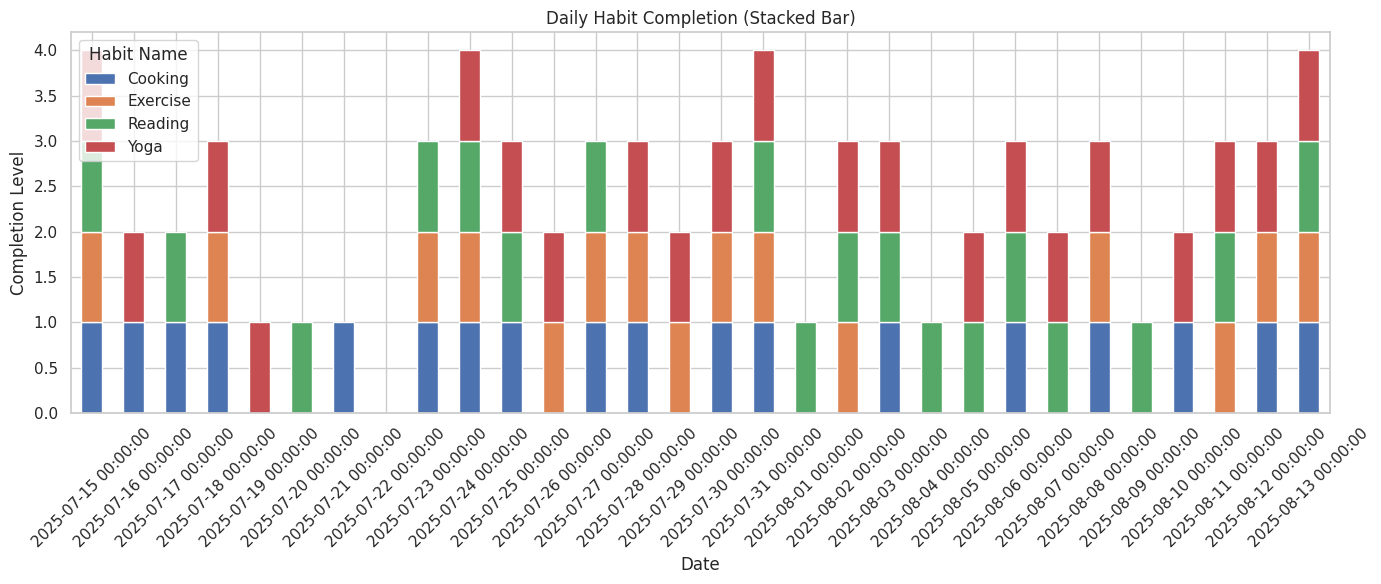

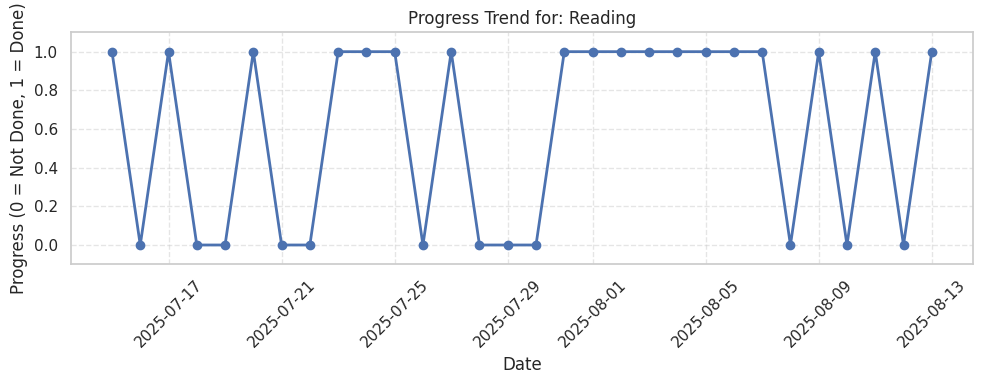

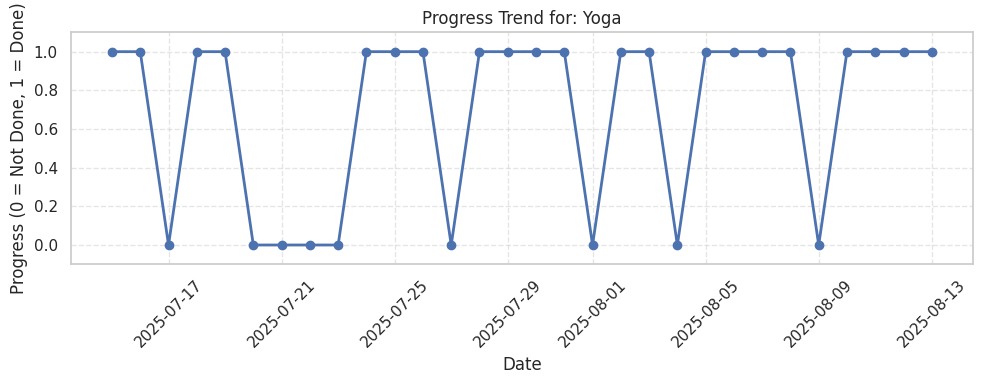

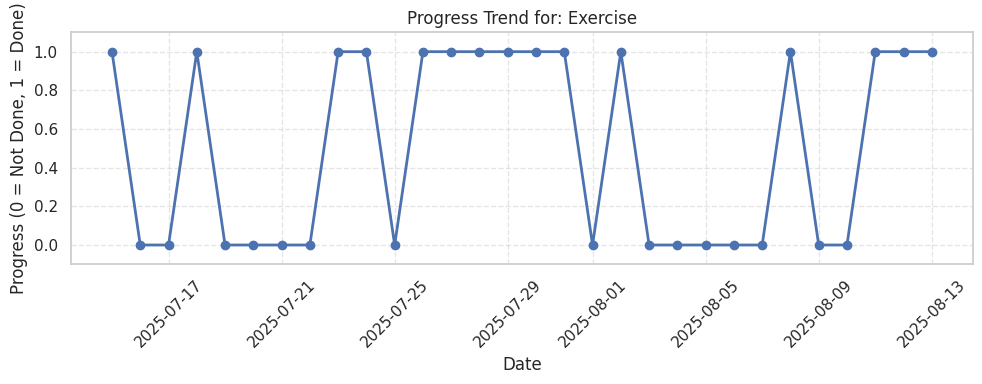

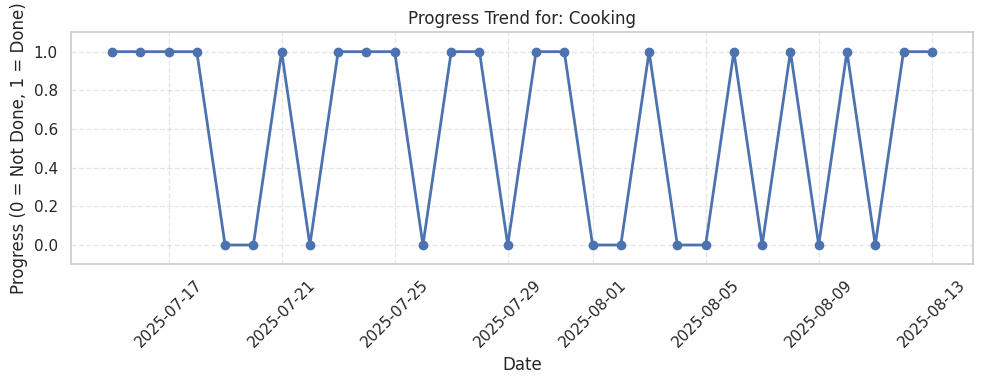

/tmp/ipython-input-3408587642.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='habit_name', y='avg_streak', data=habit_summary, palette='Blues')


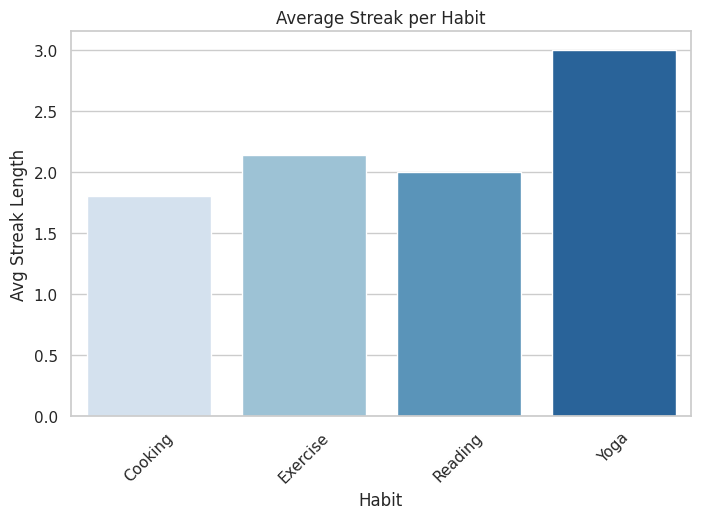


🎯 FINAL HABIT RECOMMENDATIONS:
Cooking → Focus (Score: 0.60)
Exercise → Reduce (Score: 0.50)
Reading → Reduce (Score: 0.60)
Yoga → Reduce (Score: 0.70)


In [ ]:
# ============================================
# ✅ IMPORTS
# ============================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from google.colab import files

# ============================================
# ✅ LOAD EXCEL/CSV FILE
# ============================================
print("Upload your habit tracking file (CSV or Excel)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

if filename.endswith(".xlsx"):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename, encoding='latin1')

df['date'] = pd.to_datetime(df['date'])

# ============================================
# ✅ FEATURE ENGINEERING
# ============================================

def calculate_avg_streak(series):
    streaks = []
    streak = 0
    for v in series:
        if v == 1:
            streak += 1
        else:
            if streak > 0:
                streaks.append(streak)
            streak = 0
    if streak > 0:
        streaks.append(streak)
    return np.mean(streaks) if streaks else 0

def calculate_trend(series):
    if len(series) < 14:
        return 0
    first = np.mean(series[:7])
    last = np.mean(series[-7:])
    return last - first

habit_summary = df.groupby(['user_id','habit_name']).agg(
    completion_rate=('completed','mean'),
    avg_streak=('completed', calculate_avg_streak),
    consistency=('completed','std'),
    trend=('completed', calculate_trend)
).reset_index()

habit_summary['consistency'] = habit_summary['consistency'].fillna(0)

# ============================================
# ✅ AUTO-GENERATED LABELS (NO habit_type NEEDED)
# ============================================
def auto_label(row):

    # ✅ Strong habit
    if row['completion_rate'] > 0.8 and row['trend'] >= 0:
        return "Maintain"

    # ✅ Weak habit → Needs focus
    if row['completion_rate'] < 0.5:
        return "Focus"

    # ✅ Declining habit
    if row['trend'] < -0.1:
        return "Focus"

    # ✅ Inconsistent → often reduce / manage
    if row['consistency'] > 0.4:
        return "Reduce"

    return "Okay"

habit_summary['label'] = habit_summary.apply(auto_label, axis=1)

# ============================================
# ✅ ML MODEL
# ============================================
X = habit_summary[['completion_rate','avg_streak','consistency','trend']]
y = habit_summary['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n✅ ML Model Performance:")
print(classification_report(y_test, y_pred))

# ============================================
# ✅ GRAPH SECTION – VISUAL HABIT ANALYSIS
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------
# ✅ 4. Daily Completion STACKED BAR GRAPH (per habit)
# -----------------------------

# Pivot table where each column = habit, each row = date
stack_data = df.pivot_table(
    index='date',
    columns='habit_name',
    values='completed',
    aggfunc='mean'
)

# Plot stacked bar graph
plt.figure(figsize=(14, 6))

# Ensure the index is sorted by date
stack_data = stack_data.sort_index()

stack_data.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6)
)

plt.title("Daily Habit Completion (Stacked Bar)")
plt.xlabel("Date")
plt.ylabel("Completion Level")
plt.xticks(rotation=45)
plt.legend(title="Habit Name")
plt.tight_layout()
plt.show()


# -----------------------------
# ✅ 5.SEPARATE LINE TREND GRAPH FOR EACH HABIT
# -----------------------------

# Make sure date is only date (remove time)
df['date'] = pd.to_datetime(df['date']).dt.date

# Get list of habits
unique_habits = df['habit_name'].unique()

for habit in unique_habits:
    habit_data = df[df['habit_name'] == habit].sort_values('date')

    plt.figure(figsize=(10, 4))
    plt.plot(habit_data['date'], habit_data['completed'], marker='o', linewidth=2)

    plt.title(f"Progress Trend for: {habit}")
    plt.xlabel("Date")
    plt.ylabel("Progress (0 = Not Done, 1 = Done)")
    plt.xticks(rotation=45)
    plt.ylim(-0.1, 1.1)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# -----------------------------
# ✅ 6. Streak Visualization (avg streak per habit)
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(x='habit_name', y='avg_streak', data=habit_summary, palette='Blues')
plt.title("Average Streak per Habit")
plt.xticks(rotation=45)
plt.ylabel("Avg Streak Length")
plt.xlabel("Habit")
plt.show()

# ============================================
# ✅ FINAL HABIT RECOMMENDATIONS
# ============================================
print("\n🎯 FINAL HABIT RECOMMENDATIONS:")
for _, row in habit_summary.iterrows():
    print(f"{row['habit_name']} → {row['label']} (Score: {row['completion_rate']:.2f})")


Upload your habit tracking file (CSV or Excel)


Saving Book1.xlsx to Book1 (1).xlsx

✅ ML Model Performance:
              precision    recall  f1-score   support

      Reduce       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



<Figure size 1400x600 with 0 Axes>

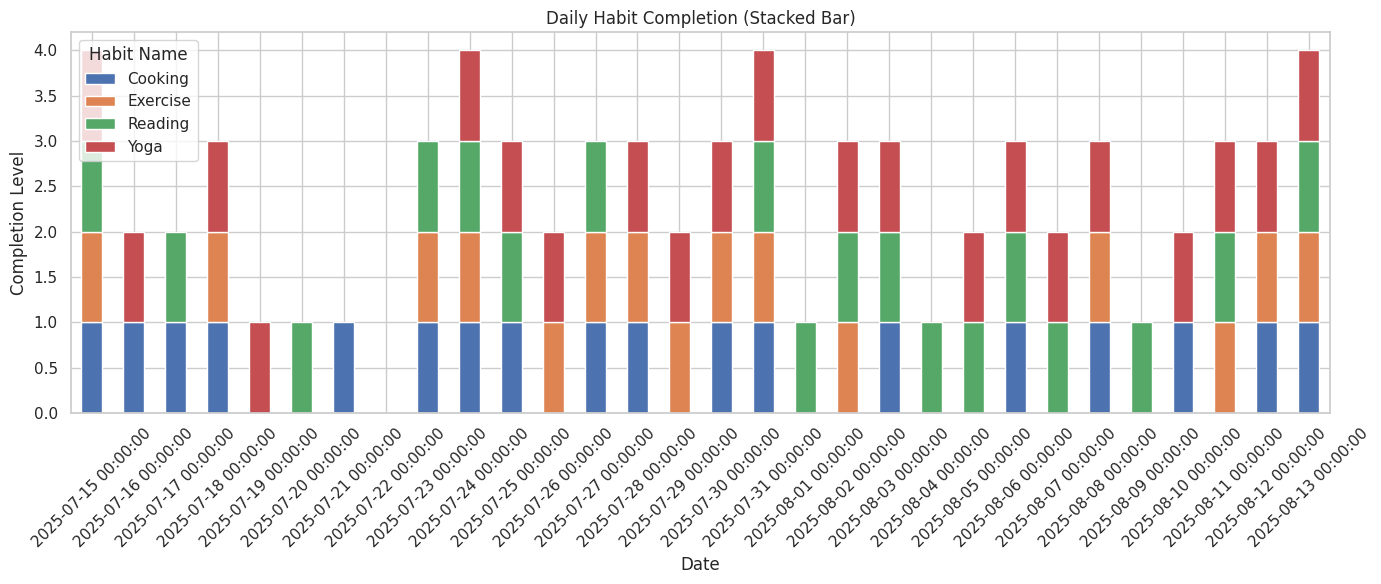

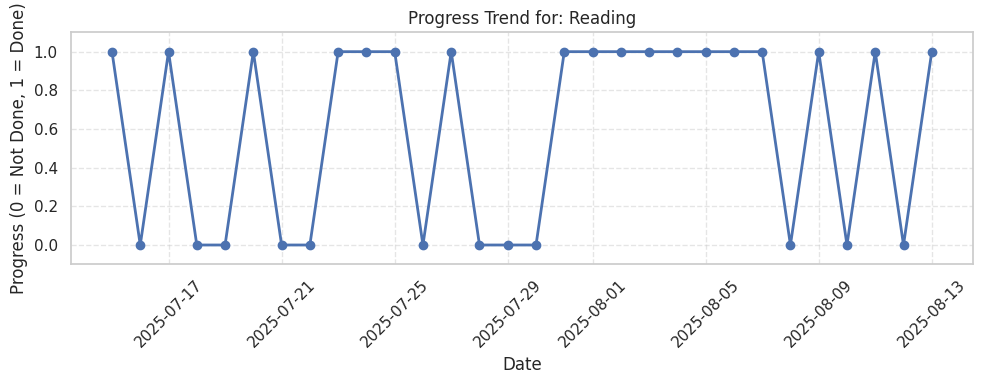

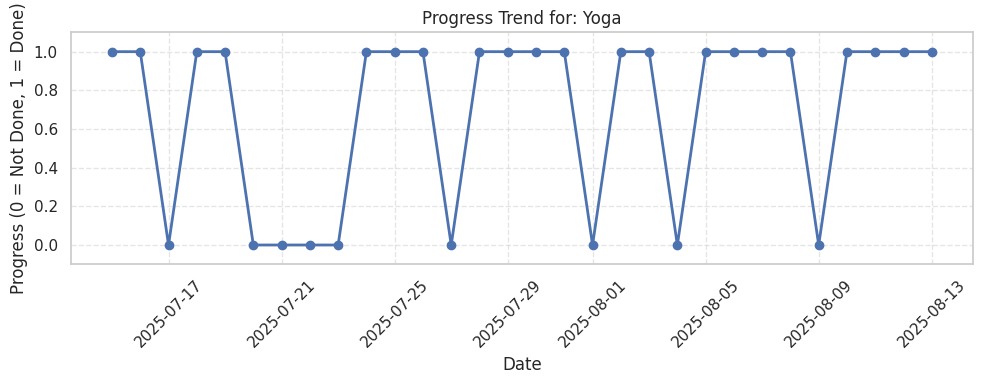

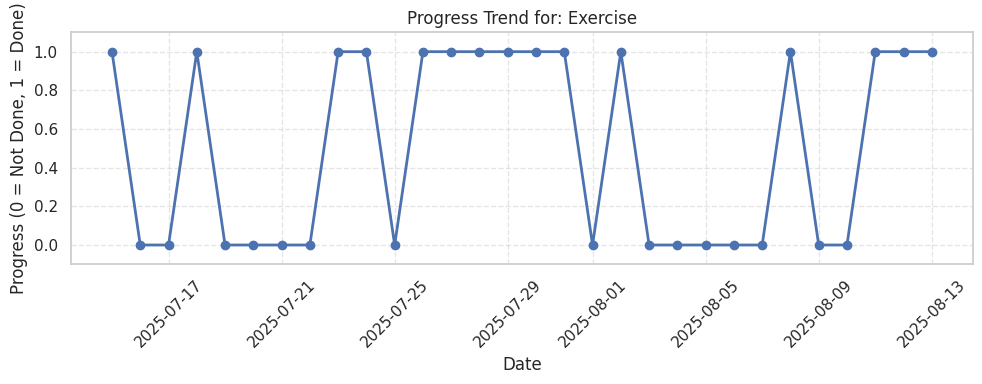

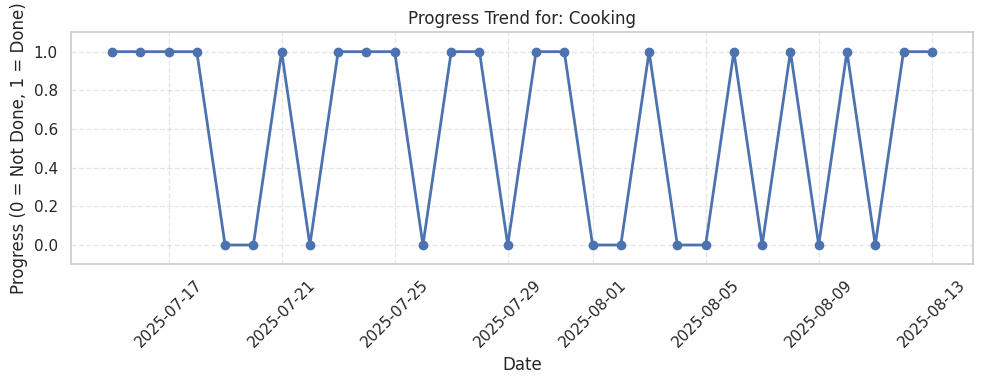

/tmp/ipython-input-3844561619.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='habit_name', y='avg_streak', data=habit_summary, palette='Blues')


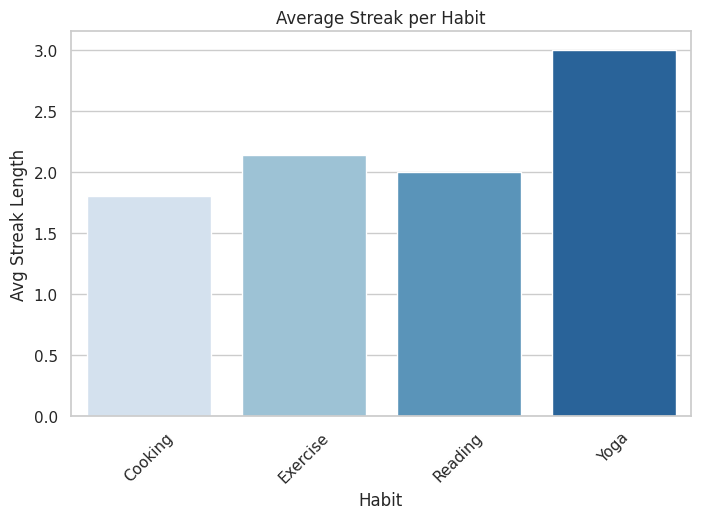

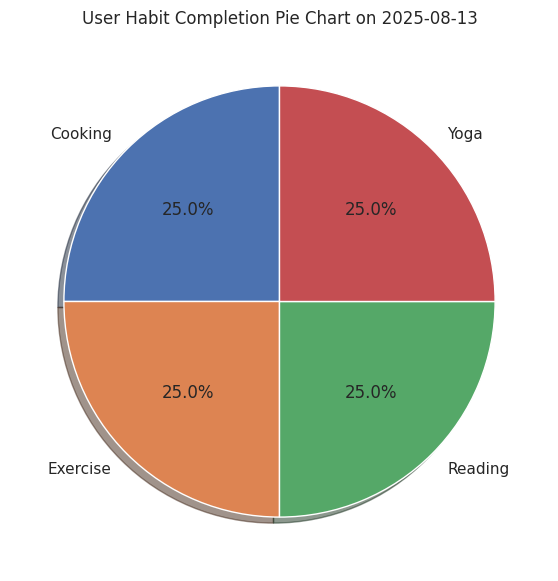

✅ Auto-generated 'habit_type' column successfully!

🎯 FINAL HABIT RECOMMENDATIONS:
Cooking → Focus (Score: 0.60)
Exercise → Reduce (Score: 0.50)
Reading → Reduce (Score: 0.60)
Yoga → Reduce (Score: 0.70)


In [ ]:
# ============================================
# ✅ IMPORTS
# ============================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from google.colab import files

# ============================================
# ✅ LOAD EXCEL/CSV FILE
# ============================================
print("Upload your habit tracking file (CSV or Excel)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

if filename.endswith(".xlsx"):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename, encoding='latin1')

df['date'] = pd.to_datetime(df['date'])

# ============================================
# ✅ FEATURE ENGINEERING
# ============================================

def calculate_avg_streak(series):
    streaks = []
    streak = 0
    for v in series:
        if v == 1:
            streak += 1
        else:
            if streak > 0:
                streaks.append(streak)
            streak = 0
    if streak > 0:
        streaks.append(streak)
    return np.mean(streaks) if streaks else 0

def calculate_trend(series):
    if len(series) < 14:
        return 0
    first = np.mean(series[:7])
    last = np.mean(series[-7:])
    return last - first

habit_summary = df.groupby(['user_id','habit_name']).agg(
    completion_rate=('completed','mean'),
    avg_streak=('completed', calculate_avg_streak),
    consistency=('completed','std'),
    trend=('completed', calculate_trend)
).reset_index()

habit_summary['consistency'] = habit_summary['consistency'].fillna(0)

# ============================================
# ✅ AUTO-GENERATED LABELS (NO habit_type NEEDED)
# ============================================
def auto_label(row):

    # ✅ Strong habit
    if row['completion_rate'] > 0.8 and row['trend'] >= 0:
        return "Maintain"

    # ✅ Weak habit → Needs focus
    if row['completion_rate'] < 0.5:
        return "Focus"

    # ✅ Declining habit
    if row['trend'] < -0.1:
        return "Focus"

    # ✅ Inconsistent → often reduce / manage
    if row['consistency'] > 0.4:
        return "Reduce"

    return "Okay"

habit_summary['label'] = habit_summary.apply(auto_label, axis=1)

# ============================================
# ✅ ML MODEL
# ============================================
X = habit_summary[['completion_rate','avg_streak','consistency','trend']]
y = habit_summary['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n✅ ML Model Performance:")
print(classification_report(y_test, y_pred))

# ============================================
# ✅ GRAPH SECTION – VISUAL HABIT ANALYSIS
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------
# ✅ 4. Daily Completion STACKED BAR GRAPH (per habit)
# -----------------------------

# Pivot table where each column = habit, each row = date
stack_data = df.pivot_table(
    index='date',
    columns='habit_name',
    values='completed',
    aggfunc='mean'
)

# Plot stacked bar graph
plt.figure(figsize=(14, 6))

# Ensure the index is sorted by date
stack_data = stack_data.sort_index()

stack_data.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6)
)

plt.title("Daily Habit Completion (Stacked Bar)")
plt.xlabel("Date")
plt.ylabel("Completion Level")
plt.xticks(rotation=45)
plt.legend(title="Habit Name")
plt.tight_layout()
plt.show()


# -----------------------------
# ✅ 5.SEPARATE LINE TREND GRAPH FOR EACH HABIT
# -----------------------------

# Make sure date is only date (remove time)
df['date'] = pd.to_datetime(df['date']).dt.date

# Get list of habits
unique_habits = df['habit_name'].unique()

for habit in unique_habits:
    habit_data = df[df['habit_name'] == habit].sort_values('date')

    plt.figure(figsize=(10, 4))
    plt.plot(habit_data['date'], habit_data['completed'], marker='o', linewidth=2)

    plt.title(f"Progress Trend for: {habit}")
    plt.xlabel("Date")
    plt.ylabel("Progress (0 = Not Done, 1 = Done)")
    plt.xticks(rotation=45)
    plt.ylim(-0.1, 1.1)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# -----------------------------
# ✅ 6. Streak Visualization (avg streak per habit)
# -----------------------------
plt.figure(figsize=(8,5))
sns.barplot(x='habit_name', y='avg_streak', data=habit_summary, palette='Blues')
plt.title("Average Streak per Habit")
plt.xticks(rotation=45)
plt.ylabel("Avg Streak Length")
plt.xlabel("Habit")
plt.show()

# ============================================
# ✅ PIE CHART: Daily Completion Distribution
# ============================================

# Convert date to pure date
df['date'] = pd.to_datetime(df['date']).dt.date

# Select the date you want to see (latest date automatically)
latest_date = df['date'].max()
today_data = df[df['date'] == latest_date]

# Count completed habits
completion_counts = today_data.groupby('habit_name')['completed'].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    completion_counts,
    labels=completion_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
plt.title(f"User Habit Completion Pie Chart on {latest_date}")
plt.show()


## ============================================
# ✅ FIX MISSING habit_type COLUMN
# ============================================

if 'habit_type' not in df.columns:

    def auto_habit_type(habit):
        h = habit.lower()

        # Negative habits (user should reduce)
        negative_keywords = ['junk', 'smoke', 'alcohol', 'game', 'gaming', 'gambling', 'fast food', 'social media']

        # Positive habits (user should increase)
        positive_keywords = ['read', 'study', 'exercise', 'workout', 'yoga', 'meditat', 'coding', 'cook', 'running', 'walking']

        if any(word in h for word in negative_keywords):
            return 'negative'
        elif any(word in h for word in positive_keywords):
            return 'positive'
        else:
            return 'neutral'

    df['habit_name'] = df['habit_name'].astype(str)
    df['habit_type'] = df['habit_name'].apply(auto_habit_type)

    print("✅ Auto-generated 'habit_type' column successfully!")

# ============================================
# ✅ FINAL HABIT RECOMMENDATIONS
# ============================================
print("\n🎯 FINAL HABIT RECOMMENDATIONS:")
for _, row in habit_summary.iterrows():
    print(f"{row['habit_name']} → {row['label']} (Score: {row['completion_rate']:.2f})")
